# Data Cleaning

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

## Inspecting dataset

In [ ]:
df = pd.read_csv('/content/Messy_Employee_dataset.csv')
df.head()

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25.0,DevOps-California,Active,4/2/2021,59767.65,bob.davis@example.com,-1651623197,Average,True
1,EMP1001,Bob,Brown,NaN,Finance-Texas,Active,7/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True
2,EMP1002,Alice,Jones,NaN,Admin-Nevada,Pending,12/7/2023,88145.90,alice.jones@example.com,-5596363211,Good,True
3,EMP1003,Eva,Davis,25.0,Admin-Nevada,Inactive,11/27/2021,69450.99,eva.davis@example.com,-3476490784,Good,True
4,EMP1004,Frank,Williams,25.0,Cloud Tech-Florida,Active,1/5/2022,109324.61,frank.williams@example.com,-1586734256,Poor,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Employee_ID        1020 non-null   object 
 1   First_Name         1020 non-null   object 
 2   Last_Name          1020 non-null   object 
 3   Age                809 non-null    float64
 4   Department_Region  1020 non-null   object 
 5   Status             1020 non-null   object 
 6   Join_Date          1020 non-null   object 
 7   Salary             996 non-null    float64
 8   Email              1020 non-null   object 
 9   Phone              1020 non-null   int64  
 10  Performance_Score  1020 non-null   object 
 11  Remote_Work        1020 non-null   bool   
dtypes: bool(1), float64(2), int64(1), object(8)
memory usage: 88.8+ KB


In [ ]:
df.describe()

,Age,Salary,Phone
count,809.000000,996.000000,1.020000e+03
mean,32.484549,85155.056396,-4.942253e+09
std,5.656860,19873.727918,2.817326e+09
min,25.000000,50047.320000,-9.994973e+09
25%,25.000000,68392.487500,-7.341992e+09
50%,30.000000,85547.870000,-4.943997e+09
75%,40.000000,100974.027500,-2.520391e+09
max,40.000000,119971.650000,-3.896086e+06


In [ ]:
df.isnull().sum()

,0
Employee_ID,0
First_Name,0
Last_Name,0
Age,211
Department_Region,0
Status,0
Join_Date,0
Salary,24
Email,0
Phone,0


## filling missing values


In [ ]:
df['Age'].fillna(df['Age'].mean(), inplace=True)

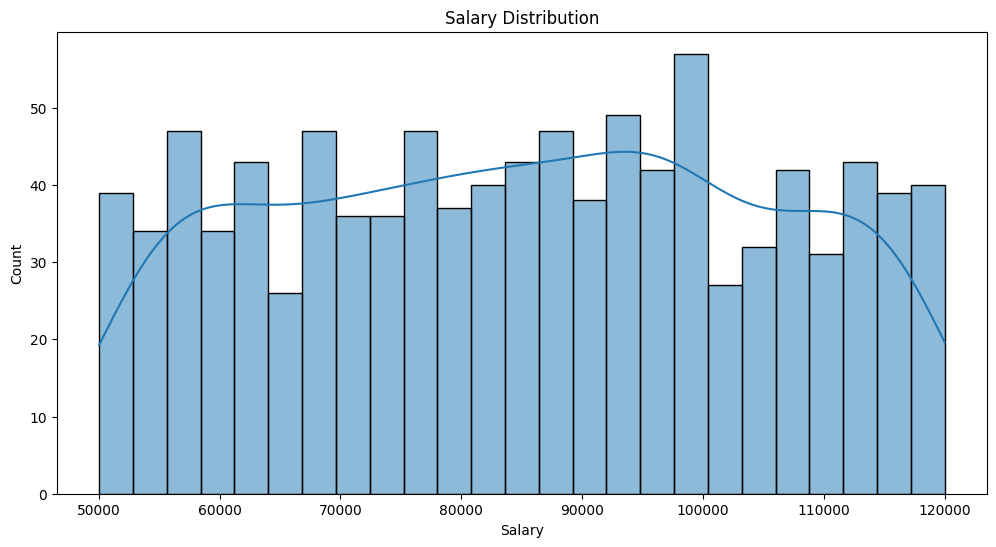

In [ ]:
plt.figure(figsize=(12,6))
plt.title('Salary Distribution')
sns.histplot(data=df, x='Salary', bins=25, kde=True)
plt.show()

In [ ]:
df['Salary'].fillna(df['Salary'].median(), inplace=True)

/tmp/ipykernel_6010/2984858743.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Salary'].fillna(df['Salary'].median(), inplace=True)


In [ ]:
df.isnull().sum()

,0
Employee_ID,0
First_Name,0
Last_Name,0
Age,0
Department_Region,0
Status,0
Join_Date,0
Salary,0
Email,0
Phone,0


## fix datatype in columns


In [ ]:
df['Age'] = df['Age'].astype('int64')
df['Phone'] = df['Phone'].astype('str')

In [ ]:
# fix phone number
df['Phone'] = df['Phone'].str.replace('-',' ')

In [ ]:
df['Phone'] = df['Phone'].str.strip()

## Checking duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

## Spliting and merging of columns

In [ ]:
df[['Department', 'location']] = df['Department_Region'].str.split('-', expand=True)

In [ ]:
df.drop('Department_Region', axis=1, inplace=True)

## Aggregations

In [ ]:
df

In [ ]:
df.groupby('Department').agg({
    'Salary':'mean',
    'location': 'count'
})

,Salary,location
Department,,
Admin,85202.644096,166
Cloud Tech,84944.434658,146
DevOps,86003.638624,189
Finance,82279.519353,170
HR,85475.379474,171
Sales,86873.948258,178
